# EDA and Data Quality Assessment | Customer Churn Risk Tool

**Key Outputs:**
1. Visual exploration of feature distributions, correlations, and churn patterns
2. Automated detection of data quality issues (duplicates, missing values, invalid dates, negative values)
3. A summary report table with recommended actions for each issue


## 1.1 Setup and Data Loading

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})

PALETTE_CHURN = {'Not Churned': '#2ecc71', 'Churned': '#e74c3c'}
PALETTE_PLAN  = {'Basic': '#3498db', 'Standard': '#9b59b6',
                'Professional': '#f39c12', 'Enterprise': '#1abc9c'}
ACCENT = '#6c5ce7'

REFERENCE_DATE = pd.Timestamp.now().normalize()
print(f"Reference date (today): {REFERENCE_DATE.date()}")

Reference date (today): 2026-08-18


In [37]:
hist_df = pd.read_csv('../data/raw/historical_customers_ds.csv',
                       parse_dates=['signup_date', 'last_login_date'])
curr_df = pd.read_csv('../data/raw/current_customers_ds.csv',
                       parse_dates=['signup_date', 'last_login_date'])

print(f"Historical dataset: {hist_df.shape[0]} rows × {hist_df.shape[1]} columns")
print(f"Current dataset:    {curr_df.shape[0]} rows × {curr_df.shape[1]} columns")

Historical dataset: 243 rows × 10 columns
Current dataset:    80 rows × 9 columns


## 1.2 Dataset Overview

In [38]:
print("=" * 60)
print("HISTORICAL DATASET — .info()")
print("=" * 60)
hist_df.info()

HISTORICAL DATASET — .info()
<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            243 non-null    str           
 1   signup_date            243 non-null    datetime64[us]
 2   plan_type              243 non-null    str           
 3   monthly_spend          242 non-null    float64       
 4   last_login_date        242 non-null    datetime64[us]
 5   num_logins_30d         242 non-null    float64       
 6   support_tickets_30d    242 non-null    float64       
 7   cancelled_flag         243 non-null    bool          
 8   preferred_language     243 non-null    str           
 9   internal_import_batch  243 non-null    str           
dtypes: bool(1), datetime64[us](2), float64(3), str(4)
memory usage: 24.3 KB


In [39]:
print("=" * 60)
print("CURRENT DATASET — .info()")
print("=" * 60)
curr_df.info()

CURRENT DATASET — .info()
<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            80 non-null     str           
 1   signup_date            80 non-null     datetime64[us]
 2   plan_type              80 non-null     str           
 3   monthly_spend          80 non-null     float64       
 4   last_login_date        80 non-null     datetime64[us]
 5   num_logins_30d         80 non-null     int64         
 6   support_tickets_30d    80 non-null     int64         
 7   preferred_language     80 non-null     str           
 8   internal_import_batch  80 non-null     str           
dtypes: datetime64[us](2), float64(1), int64(2), str(4)
memory usage: 8.0 KB


In [40]:
hist_df.head(10)

,customer_id,signup_date,plan_type,monthly_spend,last_login_date,num_logins_30d,support_tickets_30d,cancelled_flag,preferred_language,internal_import_batch
0,cust_0001,2024-02-15,Basic,17.97,2026-06-29,13.0,4.0,True,fr,import_05
1,cust_0002,2023-08-28,Enterprise,264.65,2026-06-18,18.0,3.0,False,en,import_03
2,cust_0003,2025-01-04,Professional,94.47,2026-07-26,21.0,2.0,False,fr,import_02
3,cust_0004,2025-04-03,Standard,44.93,2026-06-29,16.0,3.0,False,de,import_06
4,cust_0005,2022-12-15,Professional,95.40,2026-07-20,25.0,0.0,False,de,import_03
5,cust_0006,2025-03-04,Standard,54.83,2026-08-01,27.0,1.0,False,fr,import_07
6,cust_0007,2023-02-22,Professional,88.28,2026-07-16,21.0,1.0,True,es,import_05
7,cust_0008,2023-03-08,Standard,54.21,2026-07-06,15.0,1.0,False,pt,import_06
8,cust_0009,2022-07-22,Enterprise,254.71,2026-07-18,21.0,2.0,False,es,import_01
9,cust_0010,2024-10-31,Professional,98.57,NaT,20.0,1.0,False,pt,import_01


In [41]:
curr_df.head(10)

,customer_id,signup_date,plan_type,monthly_spend,last_login_date,num_logins_30d,support_tickets_30d,preferred_language,internal_import_batch
0,cust_1001,2025-04-23,Enterprise,223.39,2026-07-27,22,1,nl,import_02
1,cust_1002,2024-09-10,Professional,104.91,2026-05-13,0,2,de,import_06
2,cust_1003,2024-08-25,Basic,18.59,2026-08-03,24,1,de,import_05
3,cust_1004,2026-04-05,Enterprise,241.13,2026-08-04,24,3,fr,import_05
4,cust_1005,2024-06-06,Basic,17.64,2026-08-05,28,1,es,import_01
5,cust_1006,2026-01-15,Enterprise,244.70,2026-06-20,18,1,pt,import_07
6,cust_1007,2025-12-04,Enterprise,218.79,2026-07-08,20,2,nl,import_06
7,cust_1008,2026-05-13,Enterprise,260.81,2026-05-03,0,5,en,import_05
8,cust_1009,2022-10-16,Standard,44.23,2026-08-05,21,2,pt,import_04
9,cust_1010,2024-09-24,Standard,48.53,2026-07-24,15,2,es,import_01


In [42]:
hist_df.describe(include='all')

,customer_id,signup_date,plan_type,monthly_spend,last_login_date,num_logins_30d,support_tickets_30d,cancelled_flag,preferred_language,internal_import_batch
count,243,243,243,242.000000,242,242.000000,242.000000,243,243,243
unique,240,NaN,4,NaN,NaN,NaN,NaN,2,6,8
top,cust_0017,NaN,Standard,NaN,NaN,NaN,NaN,False,nl,import_05
freq,2,NaN,69,NaN,NaN,NaN,NaN,180,50,40
mean,NaN,2024-06-26 05:02:13.333333,NaN,94.289298,2026-07-02 06:44:37.685950,16.206612,2.123967,NaN,NaN,NaN
min,NaN,2022-06-28 00:00:00,NaN,-49.000000,2026-05-02 00:00:00,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,2023-06-03 12:00:00,NaN,26.762500,2026-06-08 06:00:00,11.000000,1.000000,NaN,NaN,NaN
50%,NaN,2024-07-13 00:00:00,NaN,54.145000,2026-07-10 12:00:00,17.000000,2.000000,NaN,NaN,NaN
75%,NaN,2025-07-17 00:00:00,NaN,108.267500,2026-07-28 00:00:00,22.000000,3.000000,NaN,NaN,NaN
max,NaN,2027-02-14 00:00:00,NaN,276.540000,2026-12-01 00:00:00,30.000000,6.000000,NaN,NaN,NaN


In [43]:
curr_df.describe(include='all')

,customer_id,signup_date,plan_type,monthly_spend,last_login_date,num_logins_30d,support_tickets_30d,preferred_language,internal_import_batch
count,80,80,80,80.000000,80,80.000000,80.000000,80,80
unique,80,NaN,4,NaN,NaN,NaN,NaN,6,8
top,cust_1001,NaN,Enterprise,NaN,NaN,NaN,NaN,en,import_05
freq,1,NaN,22,NaN,NaN,NaN,NaN,17,15
mean,NaN,2024-07-10 14:42:00,NaN,108.807375,2026-07-07 01:48:00,17.137500,1.987500,NaN,NaN
min,NaN,2022-07-14 00:00:00,NaN,16.840000,2026-05-03 00:00:00,0.000000,0.000000,NaN,NaN
25%,NaN,2023-07-16 06:00:00,NaN,21.230000,2026-06-21 12:00:00,12.750000,1.000000,NaN,NaN
50%,NaN,2024-07-13 00:00:00,NaN,91.810000,2026-07-18 00:00:00,18.000000,2.000000,NaN,NaN
75%,NaN,2025-06-08 06:00:00,NaN,220.202500,2026-07-31 00:00:00,22.250000,3.000000,NaN,NaN
max,NaN,2026-07-11 00:00:00,NaN,279.300000,2026-08-05 00:00:00,29.000000,5.000000,NaN,NaN


### Missing Values Overview

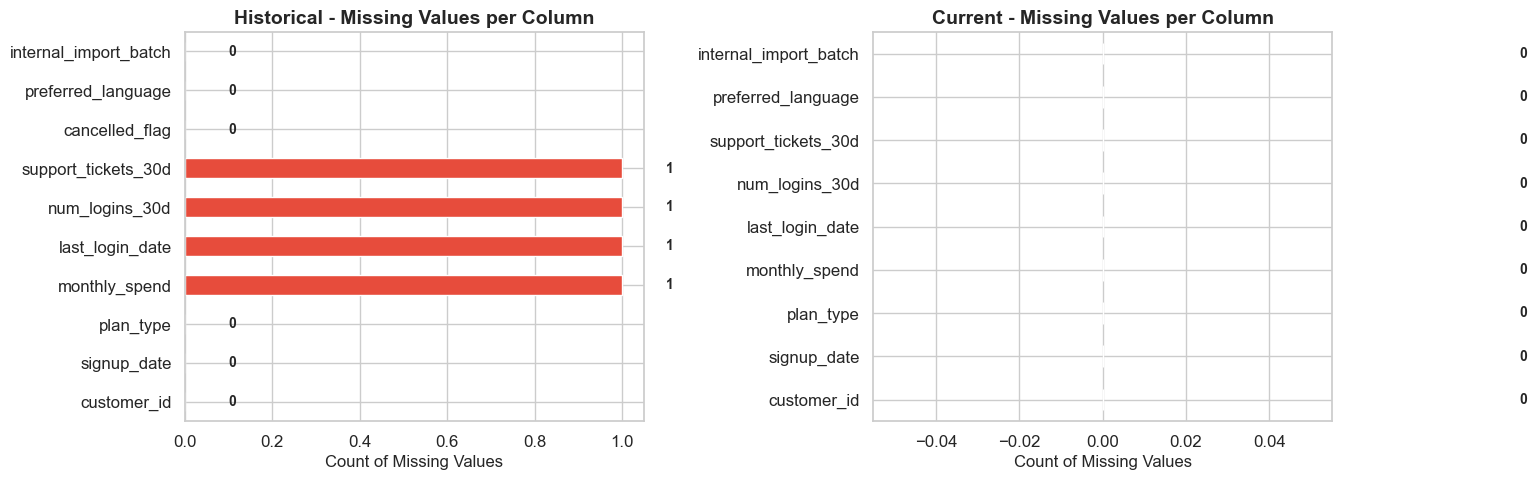

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, df) in zip(axes, [('Historical', hist_df), ('Current', curr_df)]):
    missing = df.isnull().sum()
    colors = [('#e74c3c' if v > 0 else '#2ecc71') for v in missing.values]
    missing.plot.barh(ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'{name} - Missing Values per Column', fontweight='bold')
    ax.set_xlabel('Count of Missing Values')
    for i, v in enumerate(missing.values):
        ax.text(v + 0.1, i, str(v), va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 1.3 Target Variable Analysis (Churn Distribution)

In [45]:
churn_counts = hist_df['cancelled_flag'].value_counts()
churn_pct = hist_df['cancelled_flag'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"  Not Churned (False): {churn_counts.get(False, 0)} ({churn_pct.get(False, 0):.1f}%)")
print(f"  Churned     (True):  {churn_counts.get(True, 0)} ({churn_pct.get(True, 0):.1f}%)")
print(f"\nChurn rate: {churn_pct.get(True, 0):.1f}%")

Churn Distribution:
  Not Churned (False): 180 (74.1%)
  Churned     (True):  63 (25.9%)

Churn rate: 25.9%


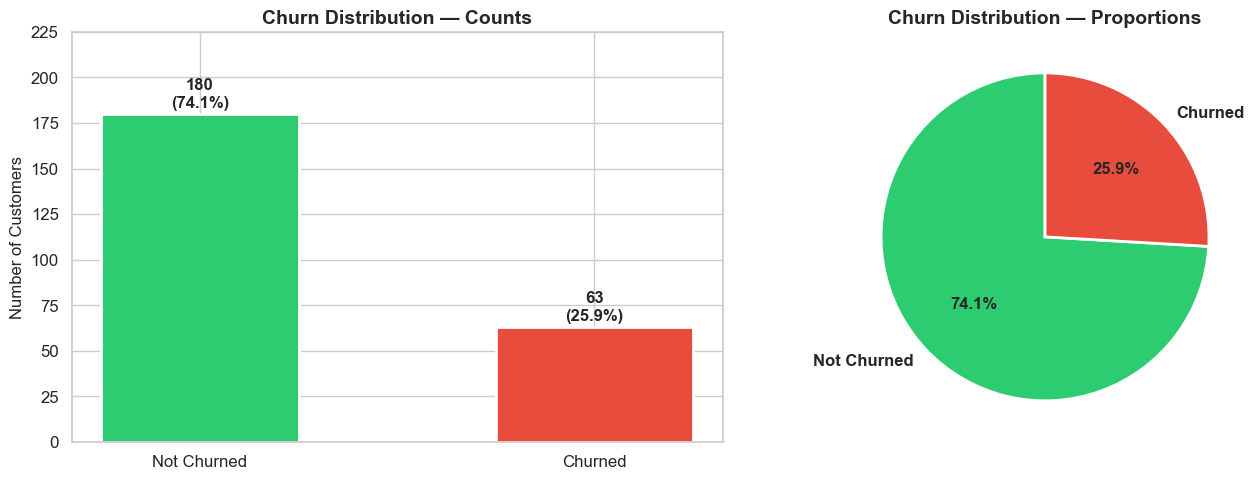

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Not Churned', 'Churned']
values = [churn_counts.get(False, 0), churn_counts.get(True, 0)]
colors = [PALETTE_CHURN['Not Churned'], PALETTE_CHURN['Churned']]

bars = axes[0].bar(labels, values, color=colors, edgecolor='white', linewidth=2, width=0.5)
for bar, val, pct in zip(bars, values, [churn_pct.get(False, 0), churn_pct.get(True, 0)]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Distribution — Counts', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, max(values) * 1.25)

axes[1].pie(values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Distribution — Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

> **Class Imbalance Note:**
> The churn rate is approximately **25.9%** (63 out of 243). While it is not severely imbalanced, the minority class (churned) is significantly smaller.

## 1.4 Feature Distributions (Historical Dataset)

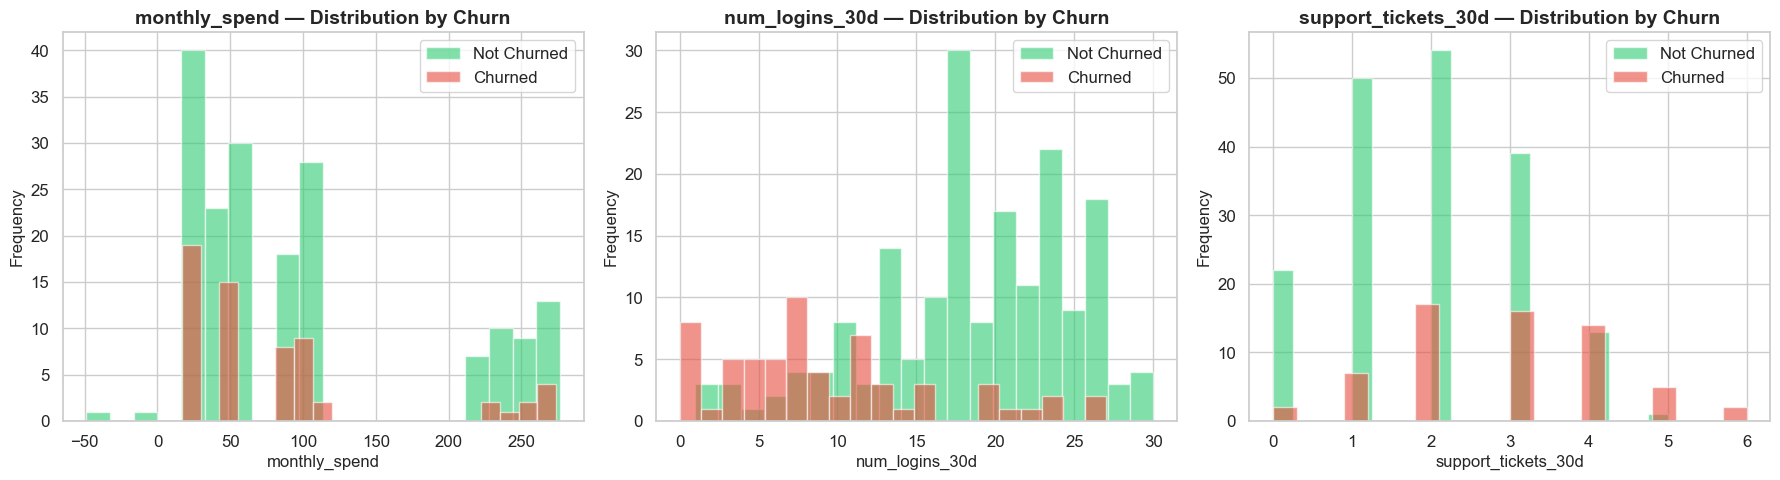

In [47]:
hist_df['churn_label'] = hist_df['cancelled_flag'].map({True: 'Churned', False: 'Not Churned'})

numeric_features = ['monthly_spend', 'num_logins_30d', 'support_tickets_30d']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, numeric_features):
    for label, color in PALETTE_CHURN.items():
        subset = hist_df[hist_df['churn_label'] == label][feat].dropna()
        ax.hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.set_title(f'{feat} — Distribution by Churn', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

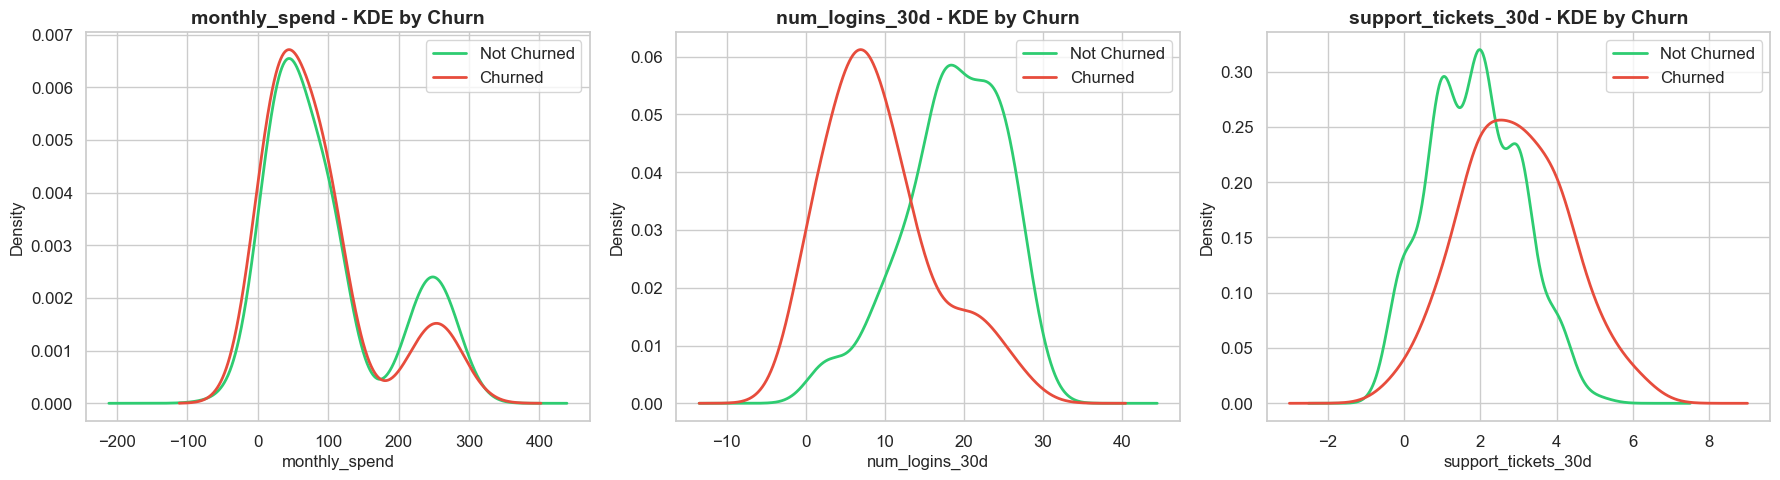

In [48]:
# KDE overlay plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, numeric_features):
    for label, color in PALETTE_CHURN.items():
        subset = hist_df[hist_df['churn_label'] == label][feat].dropna()
        if len(subset) > 1:
            subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
    ax.set_title(f'{feat} - KDE by Churn', fontweight='bold')
    ax.set_xlabel(feat)
    ax.legend()

plt.tight_layout()
plt.show()

### Box Plots - Monthly Spend by Plan Type

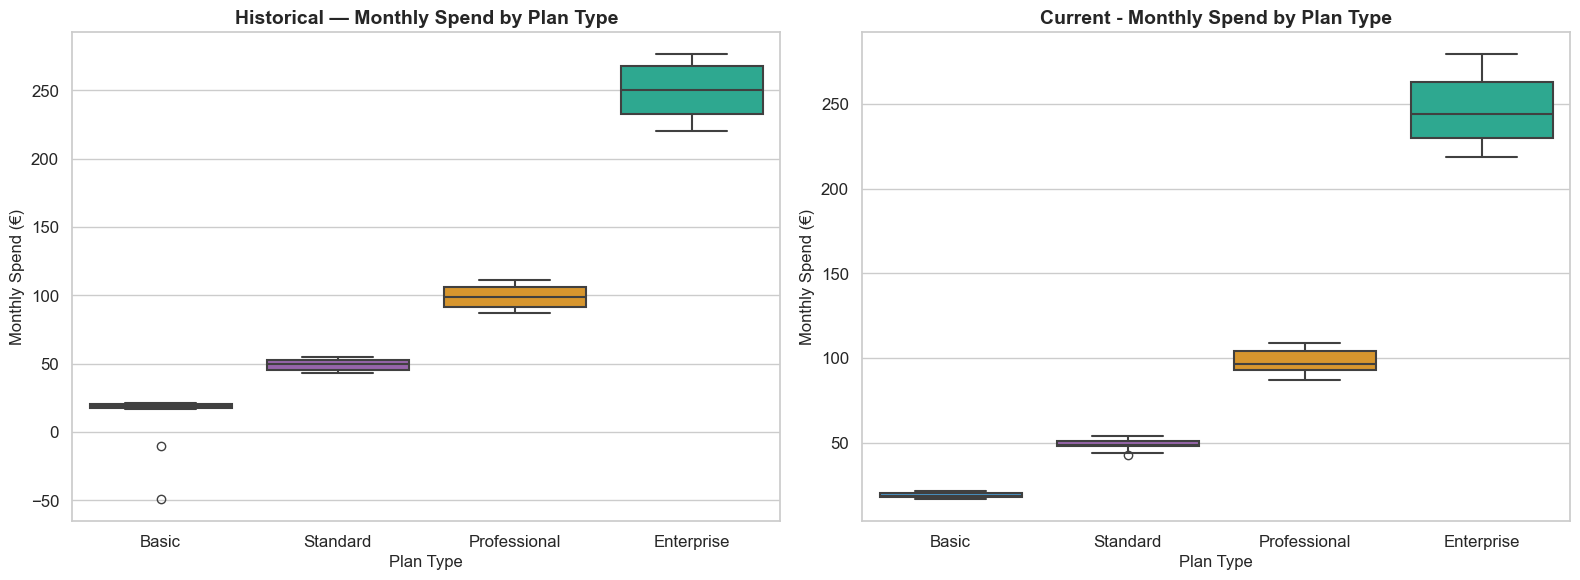

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Historical
plan_order = ['Basic', 'Standard', 'Professional', 'Enterprise']
palette_list = [PALETTE_PLAN.get(p, '#95a5a6') for p in plan_order]

sns.boxplot(data=hist_df, x='plan_type', y='monthly_spend', order=plan_order,
            palette=palette_list, ax=axes[0], linewidth=1.5)
axes[0].set_title('Historical — Monthly Spend by Plan Type', fontweight='bold')
axes[0].set_xlabel('Plan Type')
axes[0].set_ylabel('Monthly Spend (€)')

# Current
sns.boxplot(data=curr_df, x='plan_type', y='monthly_spend', order=plan_order,
            palette=palette_list, ax=axes[1], linewidth=1.5)
axes[1].set_title('Current - Monthly Spend by Plan Type', fontweight='bold')
axes[1].set_xlabel('Plan Type')
axes[1].set_ylabel('Monthly Spend (€)')

plt.tight_layout()
plt.show()

### Categorical Feature Distributions

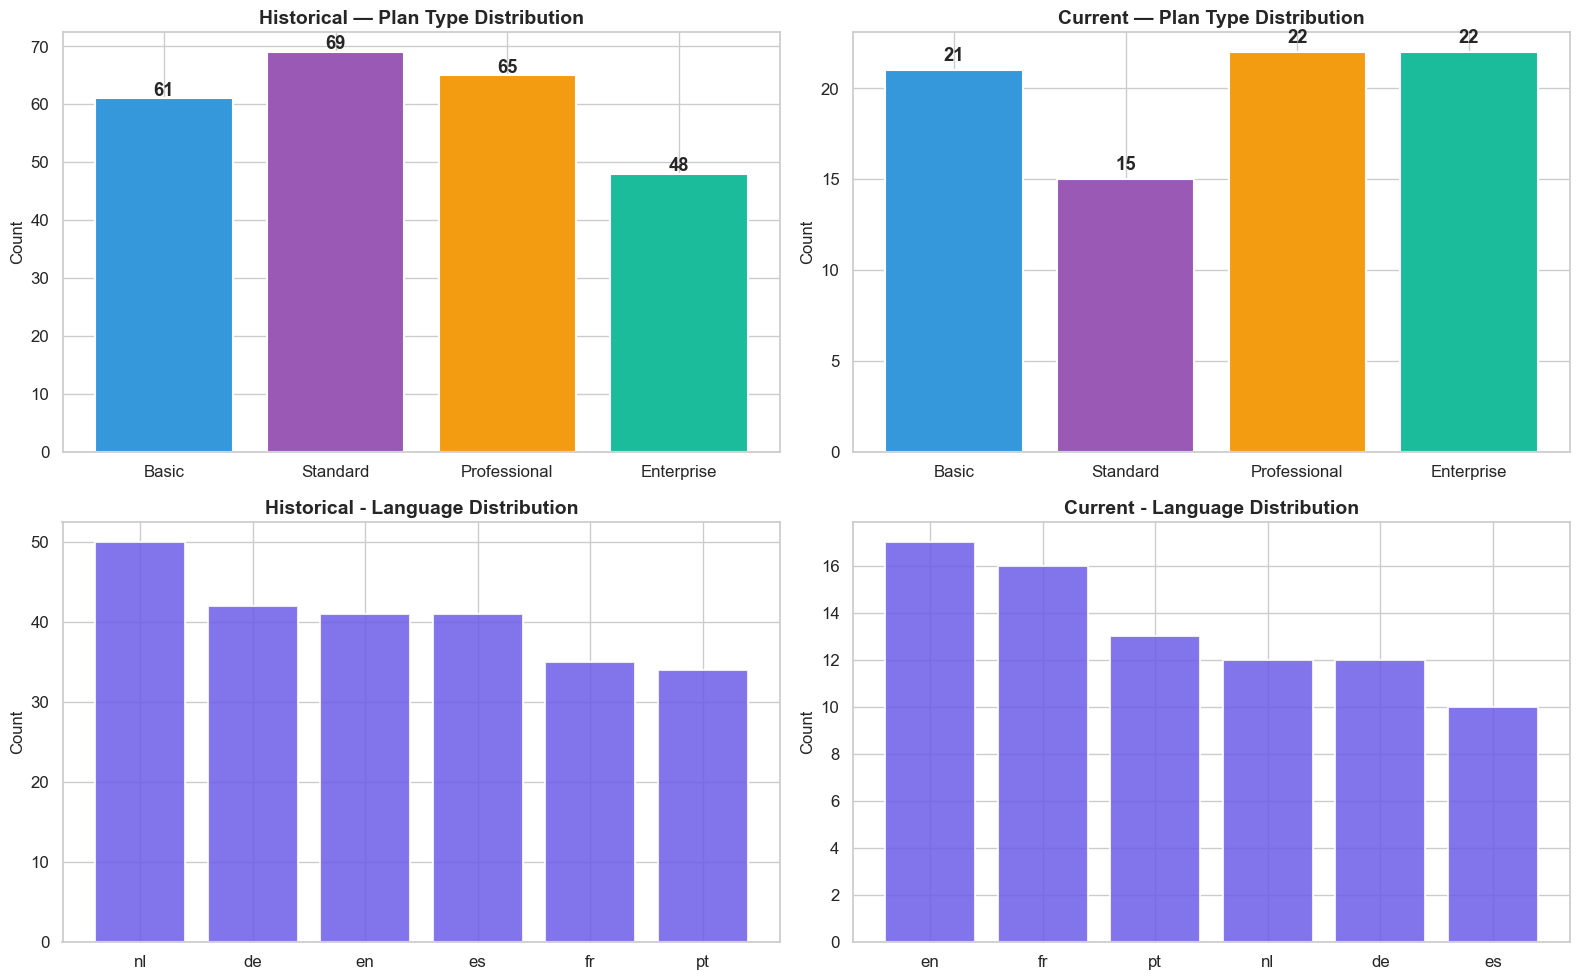

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plan type — Historical
plan_counts_h = hist_df['plan_type'].value_counts().reindex(plan_order)
axes[0, 0].bar(plan_counts_h.index, plan_counts_h.values,
                color=[PALETTE_PLAN.get(p, '#95a5a6') for p in plan_counts_h.index],
                edgecolor='white', linewidth=1.5)
axes[0, 0].set_title('Historical — Plan Type Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(plan_counts_h.values):
    axes[0, 0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Plan type — Current
plan_counts_c = curr_df['plan_type'].value_counts().reindex(plan_order)
axes[0, 1].bar(plan_counts_c.index, plan_counts_c.values,
                color=[PALETTE_PLAN.get(p, '#95a5a6') for p in plan_counts_c.index],
                edgecolor='white', linewidth=1.5)
axes[0, 1].set_title('Current — Plan Type Distribution', fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(plan_counts_c.values):
    axes[0, 1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Language — Historical
lang_counts_h = hist_df['preferred_language'].value_counts()
axes[1, 0].bar(lang_counts_h.index, lang_counts_h.values, color=ACCENT,
                edgecolor='white', linewidth=1.5, alpha=0.85)
axes[1, 0].set_title('Historical - Language Distribution', fontweight='bold')
axes[1, 0].set_ylabel('Count')

# Language — Current
lang_counts_c = curr_df['preferred_language'].value_counts()
axes[1, 1].bar(lang_counts_c.index, lang_counts_c.values, color=ACCENT,
                edgecolor='white', linewidth=1.5, alpha=0.85)
axes[1, 1].set_title('Current - Language Distribution', fontweight='bold')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 1.5 Temporal Analysis

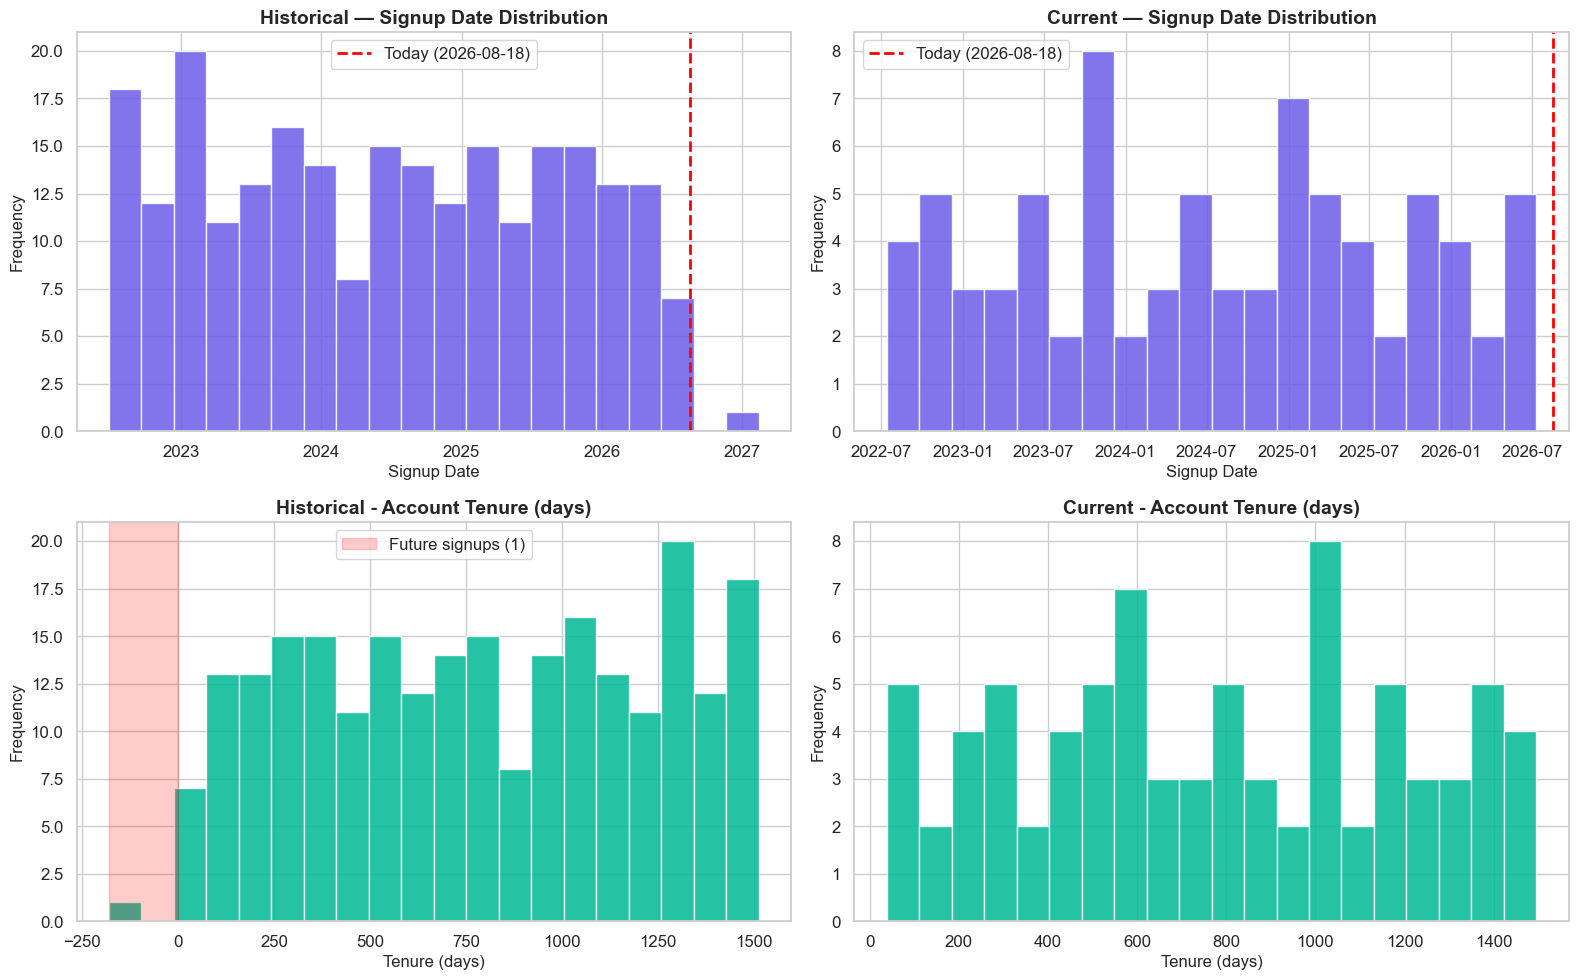

In [51]:
# Derive temporal features (RAW — before cleaning)
for df_name, df in [('hist_df', hist_df), ('curr_df', curr_df)]:
    df['account_tenure_days'] = (REFERENCE_DATE - df['signup_date']).dt.days
    df['days_since_last_login'] = (REFERENCE_DATE - df['last_login_date']).dt.days

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Signup date distribution
for ax, (name, df) in zip(axes[0], [('Historical', hist_df), ('Current', curr_df)]):
    df['signup_date'].dropna().hist(bins=20, ax=ax, color=ACCENT, edgecolor='white', alpha=0.85)
    ax.axvline(REFERENCE_DATE, color='red', linestyle='--', linewidth=2, label=f'Today ({REFERENCE_DATE.date()})')
    ax.set_title(f'{name} — Signup Date Distribution', fontweight='bold')
    ax.set_xlabel('Signup Date')
    ax.set_ylabel('Frequency')
    ax.legend()

# Account tenure
for ax, (name, df) in zip(axes[1], [('Historical', hist_df), ('Current', curr_df)]):
    tenure = df['account_tenure_days'].dropna()
    ax.hist(tenure, bins=20, color='#00b894', edgecolor='white', alpha=0.85)
    # Highlight negative tenures (future signup dates)
    neg_tenure = tenure[tenure < 0]
    if len(neg_tenure) > 0:
        ax.axvspan(tenure.min(), 0, alpha=0.2, color='red', label=f'Future signups ({len(neg_tenure)})')
        ax.legend()
    ax.set_title(f'{name} - Account Tenure (days)', fontweight='bold')
    ax.set_xlabel('Tenure (days)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

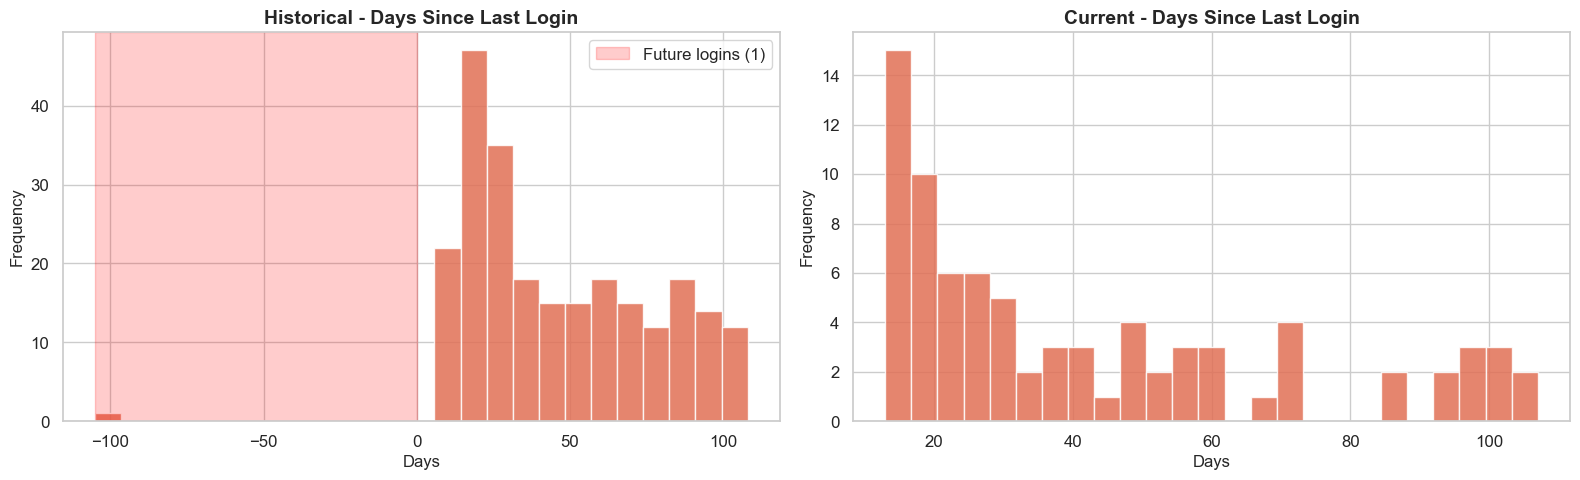

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, df) in zip(axes, [('Historical', hist_df), ('Current', curr_df)]):
    dsll = df['days_since_last_login'].dropna()
    ax.hist(dsll, bins=25, color='#e17055', edgecolor='white', alpha=0.85)
    # Highlight negative values (future logins)
    neg = dsll[dsll < 0]
    if len(neg) > 0:
        ax.axvspan(dsll.min(), 0, alpha=0.2, color='red', label=f'Future logins ({len(neg)})')
        ax.legend()
    ax.set_title(f'{name} - Days Since Last Login', fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 1.6 Correlation Analysis

Pearson correlations among numeric features (historical dataset, including derived temporal features).

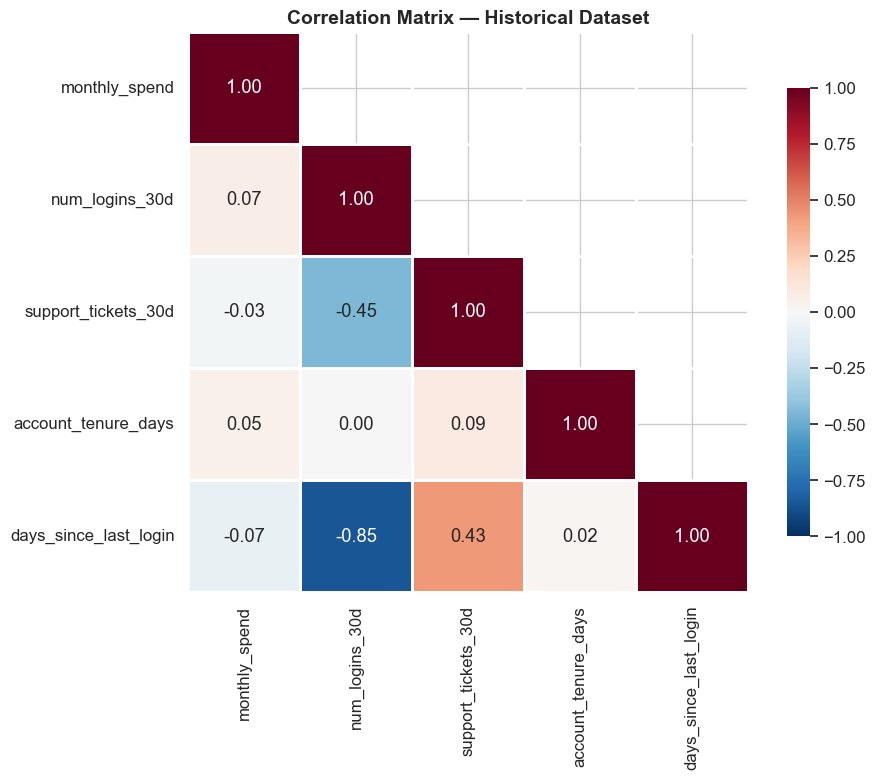

In [53]:
corr_cols = ['monthly_spend', 'num_logins_30d', 'support_tickets_30d',
             'account_tenure_days', 'days_since_last_login']

# Only use columns that exist and are numeric
available = [c for c in corr_cols if c in hist_df.columns]
corr_matrix = hist_df[available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=1, linecolor='white',
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Historical Dataset', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 1.7 Key EDA Insights

| Finding | Detail |
|---------|--------|
| **Churn rate** | ~25.9% — manageable but warrants PR-AUC as primary metric |
| **Monthly spend** | Clear separation by plan type; some anomalous negative values visible |
| **Logins (30d)** | Churned customers tend to have fewer recent logins |
| **Support tickets** | Slight right-skew; higher tickets may correlate with churn |
| **Temporal anomalies** | Some negative tenure / negative days-since-login values visible — future dates in the data |
| **Missing values** | Present in a few columns — see Data Quality section for details |

---

# Part 2: Data Quality Assessment

## 2.1 Duplicate Row Detection

In [54]:
def check_duplicates(df, dataset_name):
    """Detect duplicate rows and duplicate customer_ids."""
    print(f"{'=' * 60}")
    print(f"  DUPLICATE CHECK — {dataset_name}")
    print(f"{'=' * 60}")

    # Exact duplicate rows (excluding customer_id)
    cols_to_check = [c for c in df.columns if c not in ('customer_id', 'churn_label',
                        'account_tenure_days', 'days_since_last_login')]
    dup_mask = df.duplicated(subset=cols_to_check, keep=False)
    dup_rows = df[dup_mask].sort_values('customer_id')
    print(f"\n[1] Exact duplicate rows (same data): {dup_mask.sum()}")
    if dup_mask.sum() > 0:
        display(dup_rows[['customer_id'] + cols_to_check])

    # Duplicate customer_ids
    dup_id_mask = df.duplicated(subset=['customer_id'], keep=False)
    dup_ids = df[dup_id_mask].sort_values('customer_id')
    print(f"\n[2] Duplicate customer_ids: {dup_id_mask.sum()}")
    if dup_id_mask.sum() > 0:
        display(dup_ids[['customer_id'] + cols_to_check])

    return dup_rows, dup_ids

hist_dup_rows, hist_dup_ids = check_duplicates(hist_df, 'Historical')
print()
curr_dup_rows, curr_dup_ids = check_duplicates(curr_df, 'Current')

  DUPLICATE CHECK — Historical

[1] Exact duplicate rows (same data): 6


,customer_id,signup_date,plan_type,monthly_spend,last_login_date,num_logins_30d,support_tickets_30d,cancelled_flag,preferred_language,internal_import_batch
16,cust_0017,2023-05-28,Professional,109.75,2026-08-05,26.0,3.0,False,nl,import_08
240,cust_0017,2023-05-28,Professional,109.75,2026-08-05,26.0,3.0,False,nl,import_08
74,cust_0075,2026-06-19,Standard,53.90,2026-07-26,24.0,0.0,False,de,import_01
241,cust_0075,2026-06-19,Standard,53.90,2026-07-26,24.0,0.0,False,de,import_01
183,cust_0184,2023-02-26,Standard,43.48,2026-07-26,23.0,1.0,False,nl,import_02
242,cust_0184,2023-02-26,Standard,43.48,2026-07-26,23.0,1.0,False,nl,import_02



[2] Duplicate customer_ids: 6


,customer_id,signup_date,plan_type,monthly_spend,last_login_date,num_logins_30d,support_tickets_30d,cancelled_flag,preferred_language,internal_import_batch
16,cust_0017,2023-05-28,Professional,109.75,2026-08-05,26.0,3.0,False,nl,import_08
240,cust_0017,2023-05-28,Professional,109.75,2026-08-05,26.0,3.0,False,nl,import_08
74,cust_0075,2026-06-19,Standard,53.90,2026-07-26,24.0,0.0,False,de,import_01
241,cust_0075,2026-06-19,Standard,53.90,2026-07-26,24.0,0.0,False,de,import_01
183,cust_0184,2023-02-26,Standard,43.48,2026-07-26,23.0,1.0,False,nl,import_02
242,cust_0184,2023-02-26,Standard,43.48,2026-07-26,23.0,1.0,False,nl,import_02



  DUPLICATE CHECK — Current

[1] Exact duplicate rows (same data): 0

[2] Duplicate customer_ids: 0


## 2.2 Missing Values Analysis

In [55]:
def check_missing(df, dataset_name):
    """Analyse missing values in detail."""
    print(f"{'=' * 60}")
    print(f"  MISSING VALUES — {dataset_name}")
    print(f"{'=' * 60}")

    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    missing_summary = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
    missing_summary = missing_summary[missing_summary['Missing'] > 0]

    if missing_summary.empty:
        print("No missing values found.")
    else:
        print(f"\nColumns with missing values:")
        display(missing_summary)

    # Rows with any missing value
    rows_with_missing = df[df.isnull().any(axis=1)]
    print(f"\nRows with at least one missing value: {len(rows_with_missing)}")
    if len(rows_with_missing) > 0:
        display(rows_with_missing)

    # Check for rows with ALL numeric features missing
    numeric_cols = ['monthly_spend', 'num_logins_30d', 'support_tickets_30d']
    available_num = [c for c in numeric_cols if c in df.columns]
    if available_num:
        all_num_missing = df[df[available_num].isnull().all(axis=1)]
        if len(all_num_missing) > 0:
            print(f"\nRows with ALL numeric features ({', '.join(available_num)}) missing: {len(all_num_missing)}")
            display(all_num_missing)

    return rows_with_missing

hist_missing_rows = check_missing(hist_df, 'Historical')
print()
curr_missing_rows = check_missing(curr_df, 'Current')

  MISSING VALUES — Historical

Columns with missing values:


,Missing,Pct (%)
monthly_spend,1,0.41
last_login_date,1,0.41
num_logins_30d,1,0.41
support_tickets_30d,1,0.41
days_since_last_login,1,0.41



Rows with at least one missing value: 4


,customer_id,signup_date,plan_type,monthly_spend,last_login_date,num_logins_30d,support_tickets_30d,cancelled_flag,preferred_language,internal_import_batch,churn_label,account_tenure_days,days_since_last_login
9,cust_0010,2024-10-31,Professional,98.57,NaT,20.0,1.0,False,pt,import_01,Not Churned,656,NaN
31,cust_0032,2023-02-04,Professional,102.52,2026-06-25,NaN,4.0,False,fr,import_05,Not Churned,1291,54.0
58,cust_0059,2022-11-15,Standard,NaN,2026-05-14,2.0,2.0,True,nl,import_01,Churned,1372,96.0
92,cust_0093,2023-11-08,Professional,109.82,2026-07-30,27.0,NaN,False,nl,import_04,Not Churned,1014,19.0



  MISSING VALUES — Current
No missing values found.

Rows with at least one missing value: 0


## 2.3 Negative or Invalid Numeric Values

In [56]:
# Subscription revenue (`monthly_spend`) should never be negative. Similarly, login counts and support tickets should be >= 0.

def check_negative_values(df, dataset_name):
    """Flag negative values in numeric columns that should be non-negative."""
    print(f"{'=' * 60}")
    print(f"  NEGATIVE VALUE CHECK — {dataset_name}")
    print(f"{'=' * 60}")

    checks = {
        'monthly_spend': 'Monthly spend should be ≥ 0 (negative = possible refund or error)',
        'num_logins_30d': 'Login count should be ≥ 0',
        'support_tickets_30d': 'Support ticket count should be ≥ 0',
    }

    flagged = {}
    for col, reason in checks.items():
        if col not in df.columns:
            continue
        neg_mask = df[col] < 0
        neg_rows = df[neg_mask]
        flagged[col] = neg_rows
        status = f"{len(neg_rows)} row(s)" if len(neg_rows) > 0 else "None"
        print(f"\n  {col} < 0: {status}")
        if len(neg_rows) > 0:
            print(f"    → {reason}")
            display(neg_rows[['customer_id', col, 'plan_type']])

    return flagged

hist_neg = check_negative_values(hist_df, 'Historical')
print()
curr_neg = check_negative_values(curr_df, 'Current')

  NEGATIVE VALUE CHECK — Historical

  monthly_spend < 0: 2 row(s)
    → Monthly spend should be ≥ 0 (negative = possible refund or error)


,customer_id,monthly_spend,plan_type
117,cust_0118,-49.00,Basic
222,cust_0223,-9.99,Basic



  num_logins_30d < 0: None

  support_tickets_30d < 0: None

  NEGATIVE VALUE CHECK — Current

  monthly_spend < 0: None

  num_logins_30d < 0: None

  support_tickets_30d < 0: None


## 2.4 Date Anomaly Detection

detection:
1. **Future `signup_date`**
2. **Future `last_login_date`**
3. **`last_login_date` before `signup_date`**

In [57]:
def check_date_anomalies(df, dataset_name, reference_date):
    """Detect date anomalies automatically."""
    print(f"{'=' * 60}")
    print(f"  DATE ANOMALY CHECK — {dataset_name}")
    print(f"  Reference date: {reference_date.date()}")
    print(f"{'=' * 60}")

    anomalies = {}

    # Future signup dates
    future_signup = df[df['signup_date'] > reference_date]
    anomalies['future_signup'] = future_signup
    print(f"\n[1] Future signup dates (signup_date > {reference_date.date()}): ", end='')
    if len(future_signup) > 0:
        print(f"{len(future_signup)} row(s)")
        display(future_signup[['customer_id', 'signup_date', 'last_login_date', 'plan_type']])
    else:
        print("None")

    # Future last_login dates
    future_login = df[df['last_login_date'] > reference_date]
    anomalies['future_login'] = future_login
    print(f"\n[2] Future last_login dates (last_login_date > {reference_date.date()}): ", end='')
    if len(future_login) > 0:
        print(f"{len(future_login)} row(s)")
        display(future_login[['customer_id', 'signup_date', 'last_login_date', 'plan_type']])
    else:
        print("None")

    # Login before signup - Only check rows where both dates exist
    both_dates = df.dropna(subset=['signup_date', 'last_login_date'])
    login_before_signup = both_dates[both_dates['last_login_date'] < both_dates['signup_date']]
    anomalies['login_before_signup'] = login_before_signup
    print(f"\n[3] Last login BEFORE signup (logical inconsistency): ", end='')
    if len(login_before_signup) > 0:
        print(f"{len(login_before_signup)} row(s)")
        display(login_before_signup[['customer_id', 'signup_date', 'last_login_date', 'plan_type']])
    else:
        print("None")

    return anomalies

hist_date_anomalies = check_date_anomalies(hist_df, 'Historical', REFERENCE_DATE)
print()
curr_date_anomalies = check_date_anomalies(curr_df, 'Current', REFERENCE_DATE)

  DATE ANOMALY CHECK — Historical
  Reference date: 2026-08-18

[1] Future signup dates (signup_date > 2026-08-18): 1 row(s)


,customer_id,signup_date,last_login_date,plan_type
139,cust_0140,2027-02-14,2026-07-17,Enterprise



[2] Future last_login dates (last_login_date > 2026-08-18): 1 row(s)


,customer_id,signup_date,last_login_date,plan_type
201,cust_0202,2025-01-25,2026-12-01,Standard



[3] Last login BEFORE signup (logical inconsistency): 2 row(s)


,customer_id,signup_date,last_login_date,plan_type
139,cust_0140,2027-02-14,2026-07-17,Enterprise
165,cust_0166,2026-07-10,2026-06-20,Basic



  DATE ANOMALY CHECK — Current
  Reference date: 2026-08-18

[1] Future signup dates (signup_date > 2026-08-18): None

[2] Future last_login dates (last_login_date > 2026-08-18): None

[3] Last login BEFORE signup (logical inconsistency): 1 row(s)


,customer_id,signup_date,last_login_date,plan_type
7,cust_1008,2026-05-13,2026-05-03,Enterprise


## 2.5 Categorical Value Validation

In [58]:
EXPECTED_PLANS = {'Basic', 'Standard', 'Professional', 'Enterprise'}

def check_categoricals(df, dataset_name):
    """Validate categorical columns."""
    print(f"{'=' * 60}")
    print(f"  CATEGORICAL VALIDATION — {dataset_name}")
    print(f"{'=' * 60}")

    issues = []

    # Plan type
    actual_plans = set(df['plan_type'].dropna().unique())
    unexpected = actual_plans - EXPECTED_PLANS
    print(f"\n  plan_type unique values: {sorted(actual_plans)}")
    if unexpected:
        print(f"Unexpected plan types: {unexpected}")
        issues.append(('plan_type', unexpected))
    else:
        print(f"All plan types are valid")

    # Preferred language
    langs = df['preferred_language'].dropna().unique()
    print(f"\n  preferred_language unique values: {sorted(langs)}")
    print(f"  ({len(langs)} unique languages)")

    # internal_import_batch
    batches = df['internal_import_batch'].dropna().unique()
    print(f"\n  internal_import_batch unique values: {sorted(batches)}")
    print(f"  ({len(batches)} unique batches)")

    return issues

hist_cat_issues = check_categoricals(hist_df, 'Historical')
print()
curr_cat_issues = check_categoricals(curr_df, 'Current')

  CATEGORICAL VALIDATION — Historical

  plan_type unique values: ['Basic', 'Enterprise', 'Professional', 'Standard']
All plan types are valid

  preferred_language unique values: ['de', 'en', 'es', 'fr', 'nl', 'pt']
  (6 unique languages)

  internal_import_batch unique values: ['import_01', 'import_02', 'import_03', 'import_04', 'import_05', 'import_06', 'import_07', 'import_08']
  (8 unique batches)

  CATEGORICAL VALIDATION — Current

  plan_type unique values: ['Basic', 'Enterprise', 'Professional', 'Standard']
All plan types are valid

  preferred_language unique values: ['de', 'en', 'es', 'fr', 'nl', 'pt']
  (6 unique languages)

  internal_import_batch unique values: ['import_01', 'import_02', 'import_03', 'import_04', 'import_05', 'import_06', 'import_07', 'import_08']
  (8 unique batches)


## 2.6 Useless / Low-Information Columns

In [59]:
print("internal_import_batch — Value Counts (Historical):")
print(hist_df['internal_import_batch'].value_counts().to_string())
print()
print("internal_import_batch — Value Counts (Current):")
print(curr_df['internal_import_batch'].value_counts().to_string())

internal_import_batch — Value Counts (Historical):
internal_import_batch
import_05    40
import_07    39
import_01    39
import_03    30
import_02    26
import_06    25
import_04    23
import_08    21

internal_import_batch — Value Counts (Current):
internal_import_batch
import_05    15
import_04    14
import_07    11
import_02    10
import_01     8
import_03     8
import_06     7
import_08     7


## 2.7 Cross-Dataset Consistency

In [60]:
# Schema comparison
hist_cols = set(hist_df.columns) - {'churn_label', 'account_tenure_days', 'days_since_last_login'}
curr_cols = set(curr_df.columns) - {'churn_label', 'account_tenure_days', 'days_since_last_login'}

print("Schema Comparison:")
print(f"  Columns only in Historical: {hist_cols - curr_cols}")
print(f"  Columns only in Current:    {curr_cols - hist_cols}")
print(f"  Shared columns:             {hist_cols & curr_cols}")

# Overlapping customer IDs
overlap = set(hist_df['customer_id']) & set(curr_df['customer_id'])
print(f"\nOverlapping customer_ids: {len(overlap)}")
if overlap:
    print(f"  IDs: {sorted(overlap)}")

Schema Comparison:
  Columns only in Historical: {'cancelled_flag'}
  Columns only in Current:    set()
  Shared columns:             {'num_logins_30d', 'last_login_date', 'customer_id', 'monthly_spend', 'signup_date', 'internal_import_batch', 'support_tickets_30d', 'plan_type', 'preferred_language'}

Overlapping customer_ids: 0


# Data Quality Summary Report

| Issue | Dataset | Rows_Affected | Customer_IDs | Action |
|---|---|---|---|---|
| Exact duplicate rows | Historical | 6 | cust_0017, cust_0075, cust_0184 | Drop duplicates (keep first) 3 pair(s) |
| Negative monthly_spend | Historical | 2 | cust_0118, cust_0223 | Impute with plan-type median |
| Missing monthly_spend | Historical | 1 | cust_0059 | Impute with plan-type median  |
| Missing num_logins_30d | Historical | 1 | cust_0032 | Impute with plan-type median |
| Missing support_tickets_30d | Historical | 1 | cust_0093 | Impute with plan-type median |
| Missing last_login_date → days_since_last_login | Historical | 1 | cust_0010 | last_login_date is NaT in source → days_since_last_login imputed with median |
| Future signup_date | Historical | 1 | cust_0140 | Drop row (date clearly wrong, causes downstream inconsistencies) |
| Future last_login_date | Historical | 1 | cust_0202 | Flag → set to NaT → impute days_since_last_login with median |
| Login before signup (excl. future signups) | Historical | 1 | cust_0166 | Set last_login_date = signup_date (assume first activity = signup day) |
| Login before signup (excl. future signups) | Current | 1 | cust_1008 | Set last_login_date = signup_date (assume first activity = signup day) |
| internal_import_batch — useless column | Both | 323 | All | Drop as feature (system artifact, no predictive value) |